<a href="https://colab.research.google.com/github/harshit-coder-dev/gold-price-prediction/blob/master/Gold_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gold Price Prediction Project**



Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv('/content/Gold Price (2013-2023).csv')

In [3]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80",107.50K,0.01%
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20",105.99K,0.56%
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20",118.08K,-0.40%
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00",159.62K,0.74%
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55",NaN,0.30%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2583 non-null   object
 1   Price     2583 non-null   object
 2   Open      2583 non-null   object
 3   High      2583 non-null   object
 4   Low       2583 non-null   object
 5   Vol.      2578 non-null   object
 6   Change %  2583 non-null   object
dtypes: object(7)
memory usage: 141.4+ KB


In [5]:
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,2583,2583,2583,2583,2583,2578,2583
unique,2583,2072,2061,2044,2019,1550,474
top,01/02/2013,"1,294.30","1,325.00","1,220.00","1,314.00",0.02K,0.00%
freq,1,5,5,6,5,48,29


Rename columns

In [6]:
df.columns = ["date", "price", "open", "high", "low", "volume", "change_pct"]

In [7]:
df.columns

Index(['date', 'price', 'open', 'high', 'low', 'volume', 'change_pct'], dtype='object')

Convert Date Column

In [8]:
df['date'] = pd.to_datetime(df['date'])

Remove Commas from Price Columns

In [9]:
price_cols = ['price', 'open', 'high', 'low']
for col in price_cols:
  df[col] = df[col].str.replace(',', '').astype(float)

Clean Volume Column

In [10]:
def convert_volume(vol):
  if pd.isna(vol):
    return np.nan
  if 'K' in vol:
    return float(vol.replace('K', '')) * 1000
  return float(vol)

df['volume'] = df['volume'].apply(convert_volume)

Clean Change % Column

In [11]:
df['change_pct'] = df['change_pct'].str.replace('%','').astype(float)

Handle Missing Values

In [19]:
df.isnull().sum()

,0
date,0
price,0
open,0
high,0
low,0
volume,5
change_pct,0


In [12]:
df['volume'] = df['volume'].ffill()  # forward fill

In [13]:
df.isnull().sum()

,0
date,0
price,0
open,0
high,0
low,0
volume,0
change_pct,0


Remove Duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

Sort Data by Date

In [16]:
df = df.sort_values('date')
df.reset_index(drop= True, inplace=True)

In [17]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        2583 non-null   datetime64[ns]
 1   price       2583 non-null   float64       
 2   open        2583 non-null   float64       
 3   high        2583 non-null   float64       
 4   low         2583 non-null   float64       
 5   volume      2583 non-null   float64       
 6   change_pct  2583 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 141.4 KB


,date,price,open,high,low,volume,change_pct
0,2013-01-02,1689.9,1675.8,1695.0,1672.1,60.0,0.78
1,2013-01-03,1675.6,1688.0,1689.3,1664.3,190.0,-0.85
2,2013-01-04,1649.9,1664.4,1664.4,1630.0,310.0,-1.53
3,2013-01-07,1647.2,1657.3,1663.8,1645.3,90.0,-0.16
4,2013-01-08,1663.2,1651.5,1662.6,1648.8,130.0,0.97


Exploratory Data Analysis (EDA)

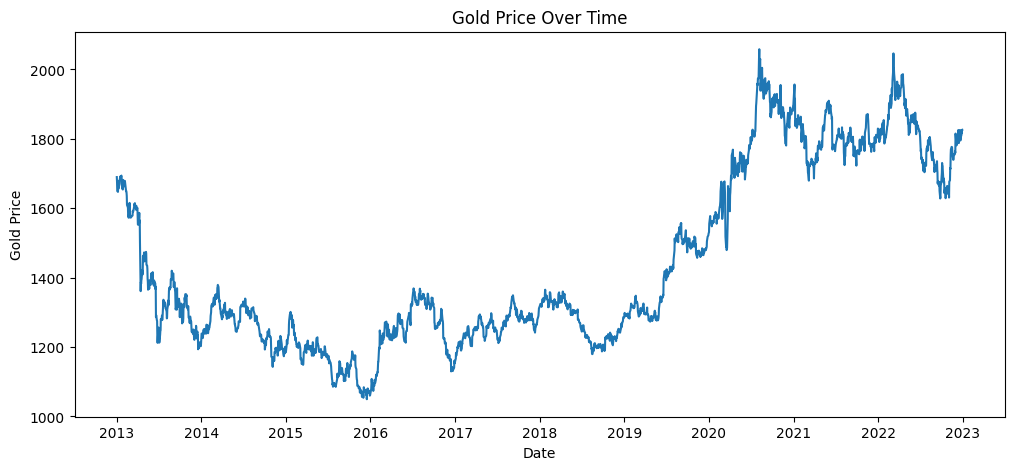

In [18]:
#Gold Price Trend

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['price'])
plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.show()

Price Distribution

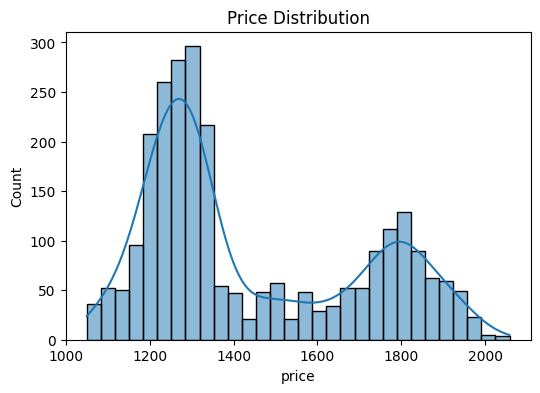

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution")
plt.show()

Volume vs Price

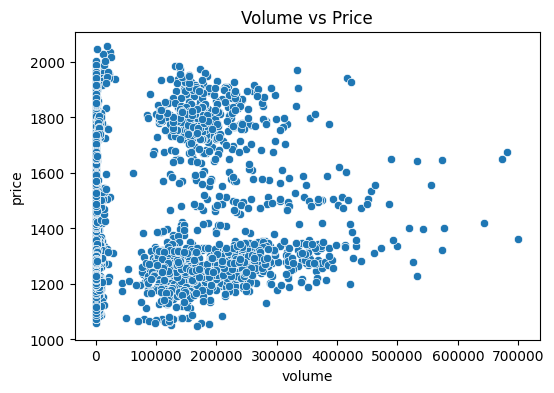

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['volume'], y=df['price'])
plt.title("Volume vs Price")
plt.show()

Correlation Heatmap

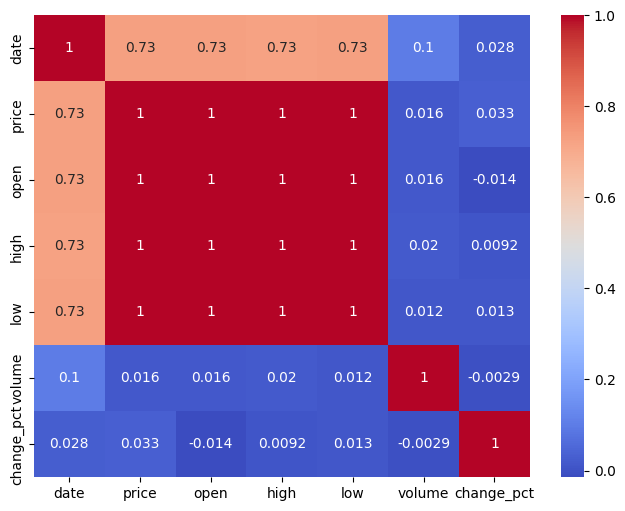

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Daily Change %

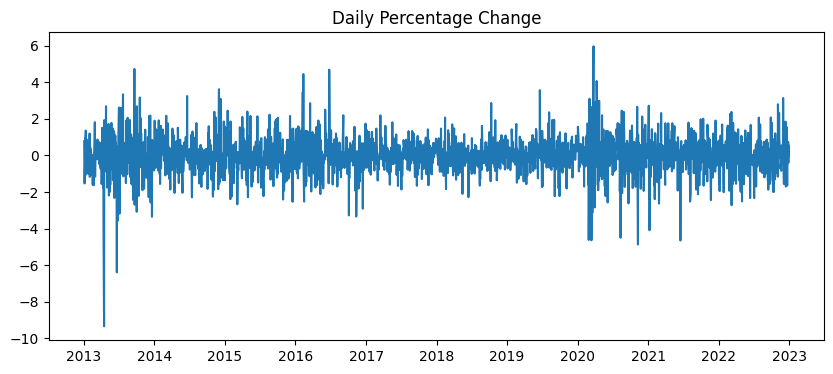

In [22]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['change_pct'])
plt.title("Daily Percentage Change")
plt.show()

###FEATURE ENGINEERING

Create price lags

In [23]:
df['price_lag_1'] = df['price'].shift(1)    # Yesterday’s price
df['price_lag_2'] = df['price'].shift(2)    # 2 days ago
df['price_lag_3'] = df['price'].shift(3)    # 3 days ago

Lag for volume

In [24]:
df['volume_lag_1'] = df['volume'].shift(1)

Rolling Mean (Trend)

In [25]:
df['rolling_mean_5'] = df['price'].rolling(window=5).mean()     # MA-5 (moving average)
df['rolling_mean_10'] = df['price'].rolling(window=10).mean()   # MA-10 (moving average)

Rolling Standard Deviation (Volatility)

In [26]:
df['rolling_std_5'] = df['price'].rolling(window=5).std()

High–Low Spread (Intraday Volatility)

In [27]:
df['high_low_spread'] = df['high'] - df['low']

Open–Close Difference (Momentum)

In [28]:
df['open_price_diff'] = df['price'] - df['open']

Percentage-Based Features

In [29]:
# pct_change() is a pandas function that calculates the percentage difference between
# one row and the one immediately before it

df['daily_return'] = df['price'].pct_change() * 100

Date-Based Features (Time Awareness)

In [30]:
# .dt accessor in pandas to extract specific components from your "date" column
# dayofweek 0 = Monday, 1 = Tuesday and so on..
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek

In [32]:
df = df.dropna()

In [31]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             2583 non-null   datetime64[ns]
 1   price            2583 non-null   float64       
 2   open             2583 non-null   float64       
 3   high             2583 non-null   float64       
 4   low              2583 non-null   float64       
 5   volume           2583 non-null   float64       
 6   change_pct       2583 non-null   float64       
 7   price_lag_1      2582 non-null   float64       
 8   price_lag_2      2581 non-null   float64       
 9   price_lag_3      2580 non-null   float64       
 10  volume_lag_1     2582 non-null   float64       
 11  rolling_mean_5   2579 non-null   float64       
 12  rolling_mean_10  2574 non-null   float64       
 13  rolling_std_5    2579 non-null   float64       
 14  high_low_spread  2583 non-null   float64

In [33]:
df.head()

,date,price,open,high,low,volume,change_pct,price_lag_1,price_lag_2,price_lag_3,...,rolling_mean_5,rolling_mean_10,rolling_std_5,high_low_spread,open_price_diff,daily_return,day,month,year,day_of_week
9,2013-01-15,1684.9,1669.7,1685.3,1669.2,230.0,0.87,1670.4,1661.6,1679.0,...,1670.48,1667.82,11.777394,16.1,15.2,0.868056,15,1,2013,1
10,2013-01-16,1684.2,1682.2,1685.2,1674.5,260.0,-0.04,1684.9,1670.4,1661.6,...,1676.02,1667.25,9.926832,10.7,2.0,-0.041545,16,1,2013,2
11,2013-01-17,1691.8,1680.9,1697.1,1668.0,530.0,0.45,1684.2,1684.9,1670.4,...,1678.58,1668.87,12.263034,29.1,10.9,0.451253,17,1,2013,3
12,2013-01-18,1688.0,1687.8,1695.8,1684.8,260.0,-0.22,1691.8,1684.2,1684.9,...,1683.86,1672.68,8.101728,11.0,0.2,-0.224613,18,1,2013,4
13,2013-01-21,1693.2,1686.5,1695.9,1684.8,165130.0,0.31,1688.0,1691.8,1684.2,...,1688.42,1677.28,4.020199,11.1,6.7,0.308057,21,1,2013,0


In [34]:
df = df.sort_values('date')
df.reset_index(drop= True, inplace=True)
df.head()

,date,price,open,high,low,volume,change_pct,price_lag_1,price_lag_2,price_lag_3,...,rolling_mean_5,rolling_mean_10,rolling_std_5,high_low_spread,open_price_diff,daily_return,day,month,year,day_of_week
0,2013-01-15,1684.9,1669.7,1685.3,1669.2,230.0,0.87,1670.4,1661.6,1679.0,...,1670.48,1667.82,11.777394,16.1,15.2,0.868056,15,1,2013,1
1,2013-01-16,1684.2,1682.2,1685.2,1674.5,260.0,-0.04,1684.9,1670.4,1661.6,...,1676.02,1667.25,9.926832,10.7,2.0,-0.041545,16,1,2013,2
2,2013-01-17,1691.8,1680.9,1697.1,1668.0,530.0,0.45,1684.2,1684.9,1670.4,...,1678.58,1668.87,12.263034,29.1,10.9,0.451253,17,1,2013,3
3,2013-01-18,1688.0,1687.8,1695.8,1684.8,260.0,-0.22,1691.8,1684.2,1684.9,...,1683.86,1672.68,8.101728,11.0,0.2,-0.224613,18,1,2013,4
4,2013-01-21,1693.2,1686.5,1695.9,1684.8,165130.0,0.31,1688.0,1691.8,1684.2,...,1688.42,1677.28,4.020199,11.1,6.7,0.308057,21,1,2013,0


## MODEL TRAINING

Target & Feature Separation

In [35]:
# we have to use time train split for prediction of prices not random test split
# In a normal train_test_split(shuffle=True), your data is picked randomly. For a stock price, this might mean:
# Training on: Monday, Wednesday, Friday
# Testing on: Tuesday, Thursday
# This is unrealistic. In the real world, you don't know Wednesday's price when you are trying to predict Tuesday.
#  Shuffling "leaks" information from the future into the past, giving you a model that looks amazingly accurate in
#  testing but fails completely when you try to use it tomorrow

X = df[
    [
        'price_lag_1',
        'price_lag_2',
        'price_lag_3',
        'volume_lag_1',
        'rolling_mean_5',
        'rolling_mean_10',
        'rolling_std_5',
        'daily_return',
        'day',
        'month',
        'day_of_week'
    ]
]

y = df['price']

In [36]:
#This code performs a manual time-series split. It divides your data into a Training set (80%) and
#a Testing set (20%) without shuffling the rows

split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]  #Takes all rows from the very beginning up to the split point for training
X_test = X.iloc[split_index:]   #Takes all rows starting from the split point to the very end for testing

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

Evaluation Metrics

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


MODEL 1: Linear Regression

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr, rmse_lr, r2_lr = evaluate_model(y_test, y_pred_lr)
print("Linear Regression:", mae_lr, rmse_lr, r2_lr)

Linear Regression: 2.713435019703855 3.835125099061478 0.9972258429442581


MODEL 2: Decision Tree Regressor

In [39]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mae_dt, rmse_dt, r2_dt = evaluate_model(y_test, y_pred_dt)
print(f"Mean Absolute Error: {mae_dt}")
print(f"Root Mean Squared Error: {rmse_dt}")
print(f"R2 Score: {r2_dt}")


Mean Absolute Error: 16.757089003039557
Root Mean Squared Error: 22.012710090430684
R2 Score: 0.9086057227907274


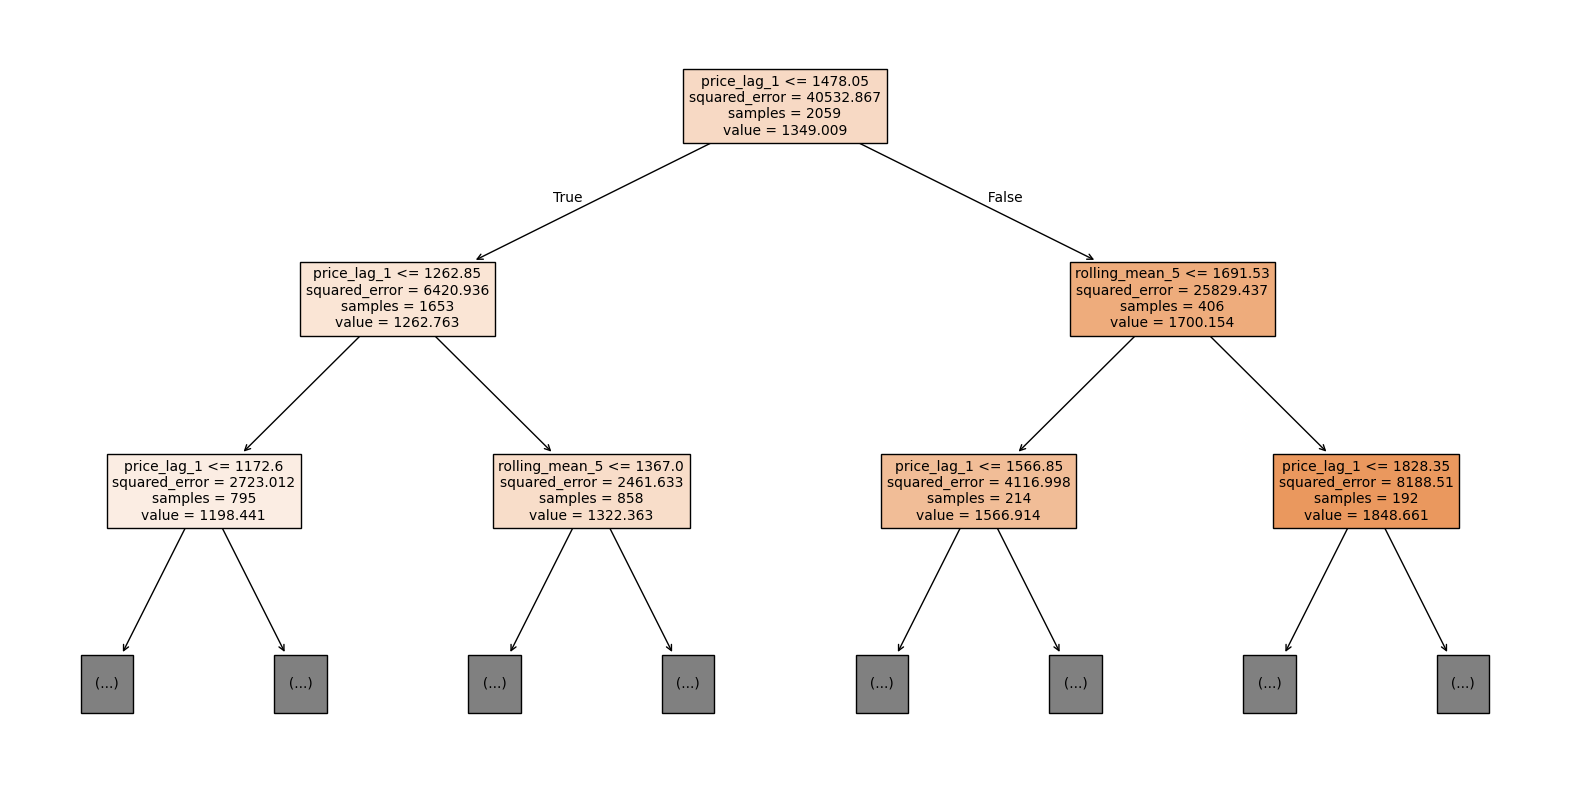

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt,
          feature_names=X.columns,
          filled=True,
          fontsize=10,
          max_depth=2)  # Viewing the top 2 levels for clarity
plt.show()

MODEL 3: Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf, rmse_rf, r2_rf = evaluate_model(y_test, y_pred_rf)
print(f"Mean Absolute Error: {mae_rf}")
print(f"Root Mean Squared Error: {rmse_rf}")
print(f"R2 Score: {r2_rf}")


Mean Absolute Error: 10.030652830421133
Root Mean Squared Error: 13.769712271429048
R2 Score: 0.9642380076773419


MODEL 4: Gradient Boosting Regressor

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

mae_gbr, rmse_gbr, r2_gbr = evaluate_model(y_test, y_pred_gbr)
print(f"Mean Absolute Error: {mae_gbr}")
print(f"Root Mean Squared Error: {rmse_gbr}")
print(f"R2 Score: {r2_gbr}")

Mean Absolute Error: 7.844292705021809
Root Mean Squared Error: 10.73449079022013
R2 Score: 0.9782662398384988


MODEL 5: XGBoost Regressor

In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb, rmse_xgb, r2_xgb = evaluate_model(y_test, y_pred_xgb)
print(f"Mean Absolute Error: {mae_xgb}")
print(f"Root Mean Squared Error: {rmse_xgb}")
print(f"R2 Score: {r2_xgb}")


Mean Absolute Error: 8.12777718256978
Root Mean Squared Error: 10.776047314716843
R2 Score: 0.9780976379369255


Model Comparison Table

In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [mae_lr, mae_dt, mae_rf, mae_gbr, mae_xgb],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf, rmse_gbr, rmse_xgb],
    "R2 Score": [r2_lr, r2_dt, r2_rf, r2_gbr, r2_xgb]
})

results.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.713435,3.835125,0.997226
3,Gradient Boosting,7.844293,10.734491,0.978266
4,XGBoost,8.127777,10.776047,0.978098
2,Random Forest,10.030653,13.769712,0.964238
1,Decision Tree,16.757089,22.012710,0.908606


In [45]:
df[['price', 'price_lag_1']].corr()

,price,price_lag_1
price,1.000000,0.998383
price_lag_1,0.998383,1.000000


In [46]:
X.columns

Index(['price_lag_1', 'price_lag_2', 'price_lag_3', 'volume_lag_1',
       'rolling_mean_5', 'rolling_mean_10', 'rolling_std_5', 'daily_return',
       'day', 'month', 'day_of_week'],
      dtype='object')

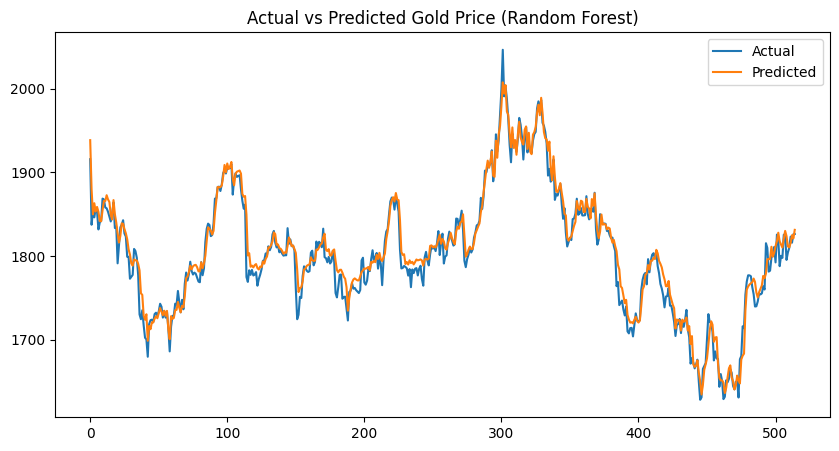

In [47]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Gold Price (Random Forest)")
plt.show()

## Feature Importance

Feature Importance – Random Forest

In [48]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=300, random_state=42)

In [49]:
import pandas as pd

rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

rf_importance


,feature,importance
0,price_lag_1,0.734700
4,rolling_mean_5,0.249626
5,rolling_mean_10,0.006376
1,price_lag_2,0.005641
7,daily_return,0.002669
2,price_lag_3,0.000364
6,rolling_std_5,0.000283
9,month,0.000125
8,day,0.000087
3,volume_lag_1,0.000086


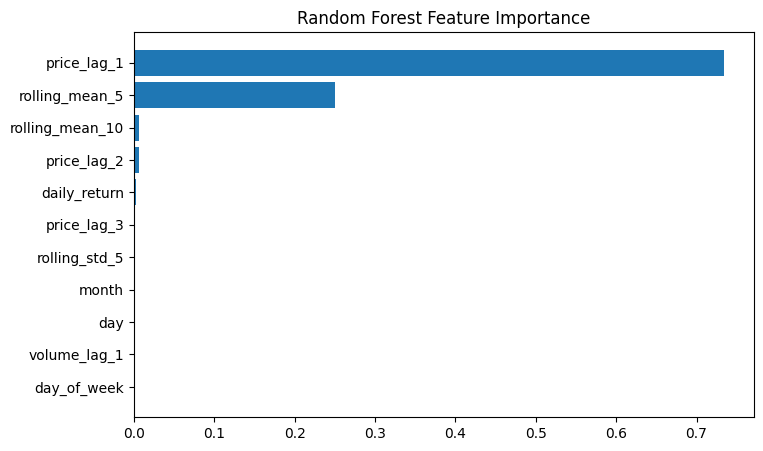

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(rf_importance['feature'], rf_importance['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

Feature Importance – XGBoost

In [51]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [52]:
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

xgb_importance

,feature,importance
4,rolling_mean_5,0.739999
0,price_lag_1,0.234173
1,price_lag_2,0.012368
5,rolling_mean_10,0.012025
7,daily_return,0.001149
9,month,0.000146
6,rolling_std_5,0.000041
3,volume_lag_1,0.000032
8,day,0.000028
2,price_lag_3,0.000021


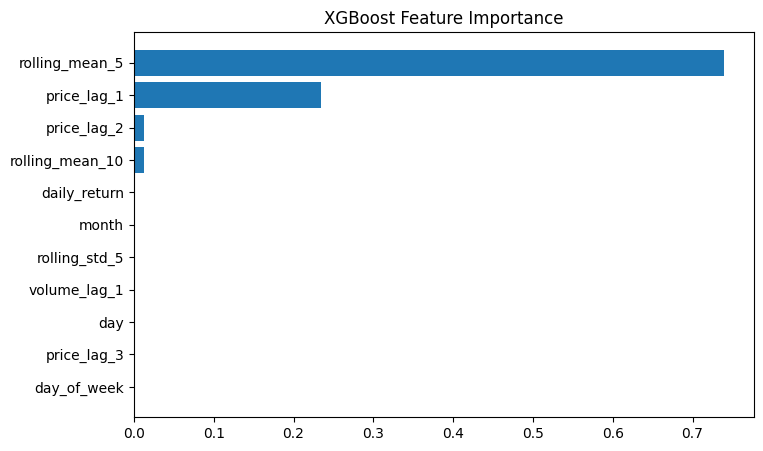

In [53]:
plt.figure(figsize=(8,5))
plt.barh(xgb_importance['feature'], xgb_importance['importance'])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()


Feature Importance – Linear Regression

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [55]:
lr_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values(by='coefficient', key=abs, ascending=False)

lr_importance

,feature,coefficient
0,price_lag_1,189.317180
4,rolling_mean_5,29.982745
7,daily_return,13.411157
2,price_lag_3,-12.407132
1,price_lag_2,-5.487385
5,rolling_mean_10,-0.282100
6,rolling_std_5,-0.176454
9,month,0.065077
10,day_of_week,-0.044445
8,day,0.036429


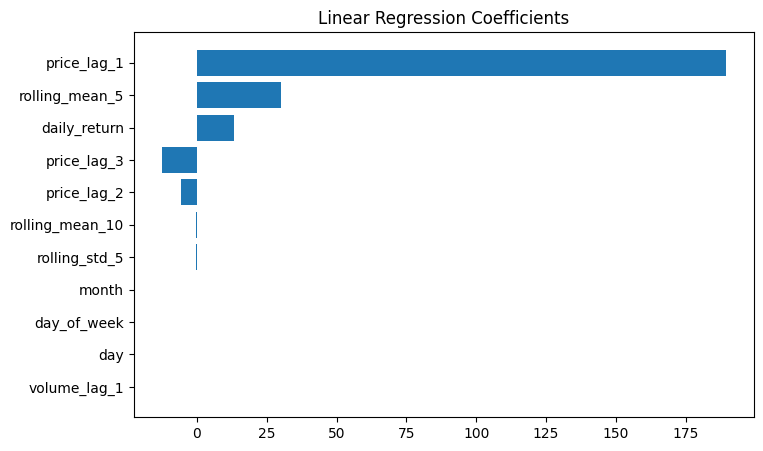

In [56]:
plt.figure(figsize=(8,5))
plt.barh(lr_importance['feature'], lr_importance['coefficient'])
plt.gca().invert_yaxis()
plt.title("Linear Regression Coefficients")
plt.show()

Model-Agnostic Feature Importance

In [57]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance

,feature,importance
0,price_lag_1,0.770870
4,rolling_mean_5,0.178203
7,daily_return,0.036955
5,rolling_mean_10,0.008176
1,price_lag_2,0.001939
6,rolling_std_5,0.000875
8,day,0.000410
10,day_of_week,0.000248
2,price_lag_3,0.000163
3,volume_lag_1,0.000125


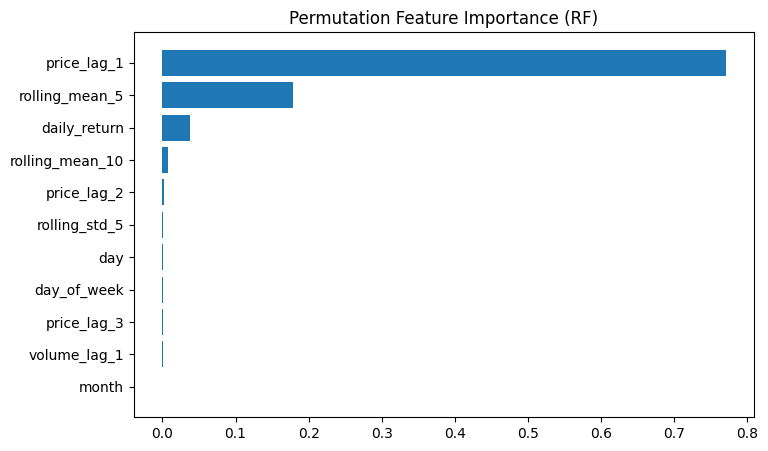

In [58]:
plt.figure(figsize=(8,5))
plt.barh(perm_importance['feature'], perm_importance['importance'])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance (RF)")
plt.show()

## Predict Tomorrow’s Gold Price

prediction using linear regression

In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [61]:
last_row = df.iloc[-1]  # Get last available row

In [62]:
import pandas as pd
import numpy as np

tomorrow_features = pd.DataFrame({
    'price_lag_1': [last_row['price']],
    'price_lag_2': [df.iloc[-2]['price']],
    'price_lag_3': [df.iloc[-3]['price']],
    'volume_lag_1': [last_row['volume']],
    'rolling_mean_5': [df['price'].iloc[-5:].mean()],
    'rolling_mean_10': [df['price'].iloc[-10:].mean()],
    'rolling_std_5': [df['price'].iloc[-5:].std()],
    'daily_return': [df['daily_return'].iloc[-1]],
    'day': [(last_row['date'] + pd.Timedelta(days=1)).day],
    'month': [(last_row['date'] + pd.Timedelta(days=1)).month],
    'day_of_week': [(last_row['date'] + pd.Timedelta(days=1)).dayofweek]
})


In [63]:
tomorrow_price = model.predict(tomorrow_features)

print("Predicted Gold Price for Tomorrow:", round(tomorrow_price[0], 2))

Predicted Gold Price for Tomorrow: 1826.3


Prediction Using XGBoost

In [64]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X, y)
xgb_tomorrow = xgb.predict(tomorrow_features)

print("XGBoost Prediction:", round(xgb_tomorrow[0], 2))

XGBoost Prediction: 1826.64


## Predict next 7 / 30 days

In [65]:
from sklearn.linear_model import LinearRegression

final_model = LinearRegression()
final_model.fit(X, y)

LinearRegression()

In [66]:
def predict_future_prices(df, model, days_ahead):
    df_future = df.copy()
    future_predictions = []

    for _ in range(days_ahead):
        last_row = df_future.iloc[-1]

        next_date = last_row['date'] + pd.Timedelta(days=1)

        next_features = pd.DataFrame({
            'price_lag_1': [last_row['price']],
            'price_lag_2': [df_future.iloc[-2]['price']],
            'price_lag_3': [df_future.iloc[-3]['price']],
            'volume_lag_1': [last_row['volume']],
            'rolling_mean_5': [df_future['price'].iloc[-5:].mean()],
            'rolling_mean_10': [df_future['price'].iloc[-10:].mean()],
            'rolling_std_5': [df_future['price'].iloc[-5:].std()],
            'daily_return': [df_future['daily_return'].iloc[-1]],
            'day': [next_date.day],
            'month': [next_date.month],
            'day_of_week': [next_date.dayofweek]
        })

        next_price = model.predict(next_features)[0]

        future_predictions.append({
            'date': next_date,
            'predicted_price': next_price
        })

        # Append predicted price so it can be used for next step
        new_row = last_row.copy()
        new_row['date'] = next_date
        new_row['price'] = next_price

        df_future = pd.concat(
            [df_future, pd.DataFrame([new_row])],
            ignore_index=True
        )

    return pd.DataFrame(future_predictions)


Predict Next 7 Days

In [67]:
forecast_7_days = predict_future_prices(df, final_model, days_ahead=7)
forecast_7_days

,date,predicted_price
0,2022-12-31,1826.299836
1,2023-01-01,1825.888432
2,2023-01-02,1825.751584
3,2023-01-03,1826.091806
4,2023-01-04,1826.382289
5,2023-01-05,1826.604010
6,2023-01-06,1826.740946


Predict Next 30 Days

In [68]:
forecast_30_days = predict_future_prices(df, final_model, days_ahead=30)
forecast_30_days

,date,predicted_price
0,2022-12-31,1826.299836
1,2023-01-01,1825.888432
2,2023-01-02,1825.751584
3,2023-01-03,1826.091806
4,2023-01-04,1826.382289
5,2023-01-05,1826.604010
6,2023-01-06,1826.740946
7,2023-01-07,1826.844823
8,2023-01-08,1826.929222
9,2023-01-09,1827.180171


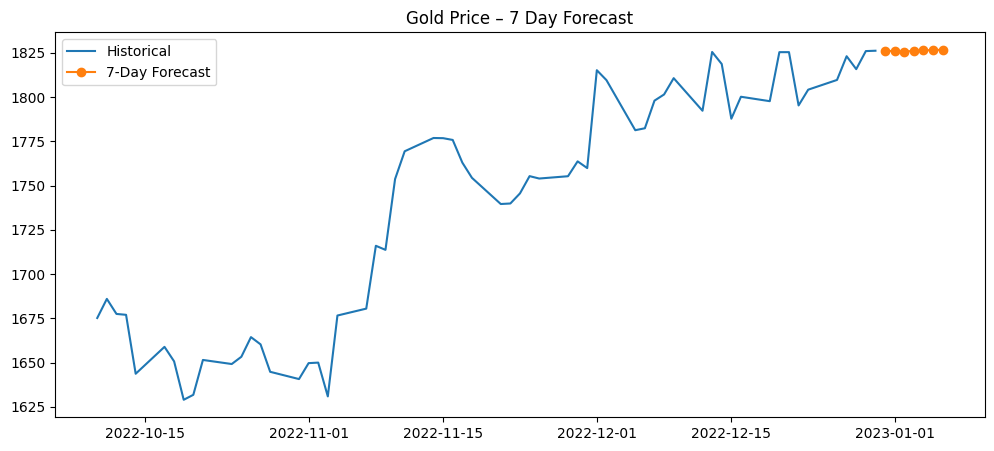

In [69]:
plt.figure(figsize=(12,5))

plt.plot(df['date'].iloc[-60:], df['price'].iloc[-60:], label='Historical')
plt.plot(forecast_7_days['date'], forecast_7_days['predicted_price'],
         marker='o', label='7-Day Forecast')

plt.legend()
plt.title("Gold Price – 7 Day Forecast")
plt.show()

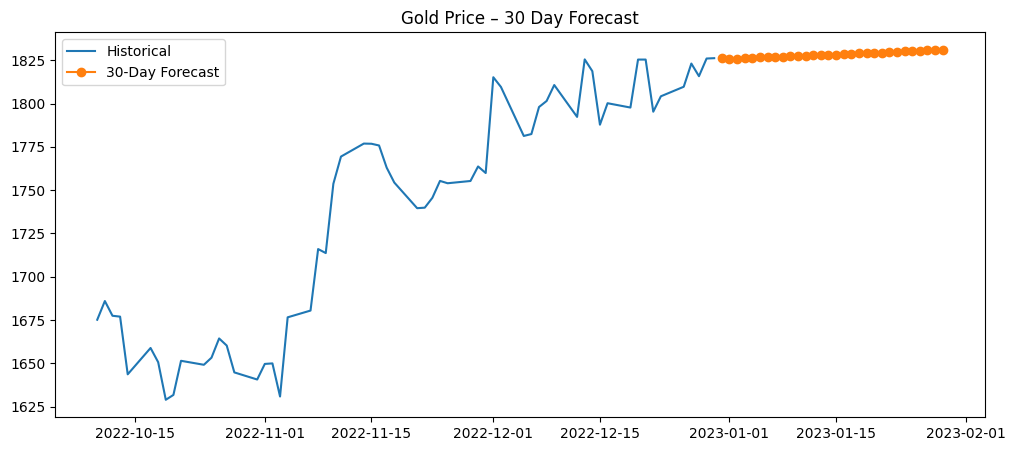

In [70]:
plt.figure(figsize=(12,5))

plt.plot(df['date'].iloc[-60:], df['price'].iloc[-60:], label='Historical')
plt.plot(forecast_30_days['date'], forecast_30_days['predicted_price'],
         marker='o', label='30-Day Forecast')

plt.legend()
plt.title("Gold Price – 30 Day Forecast")
plt.show()

Train Final XGBoost Model on ALL Data

In [71]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [72]:
def predict_future_prices_xgb(df, model, days_ahead):
    df_future = df.copy()
    future_predictions = []

    for _ in range(days_ahead):
        last_row = df_future.iloc[-1]
        next_date = last_row['date'] + pd.Timedelta(days=1)

        next_features = pd.DataFrame({
            'price_lag_1': [df_future.iloc[-1]['price']],
            'price_lag_2': [df_future.iloc[-2]['price']],
            'price_lag_3': [df_future.iloc[-3]['price']],
            'volume_lag_1': [df_future.iloc[-1]['volume']],
            'rolling_mean_5': [df_future['price'].iloc[-5:].mean()],
            'rolling_mean_10': [df_future['price'].iloc[-10:].mean()],
            'rolling_std_5': [df_future['price'].iloc[-5:].std()],
            'daily_return': [df_future['daily_return'].iloc[-1]],
            'day': [next_date.day],
            'month': [next_date.month],
            'day_of_week': [next_date.dayofweek]
        })

        next_price = model.predict(next_features)[0]

        future_predictions.append({
            'date': next_date,
            'predicted_price': next_price
        })

        # Create new row for recursive use
        new_row = last_row.copy()
        new_row['date'] = next_date
        new_row['price'] = next_price

        df_future = pd.concat(
            [df_future, pd.DataFrame([new_row])],
            ignore_index=True
        )

    return pd.DataFrame(future_predictions)

In [73]:
forecast_7_days_xgb = predict_future_prices_xgb(
    df, xgb_model, days_ahead=7
)
forecast_30_days_xgb = predict_future_prices_xgb(
    df, xgb_model, days_ahead=30
)


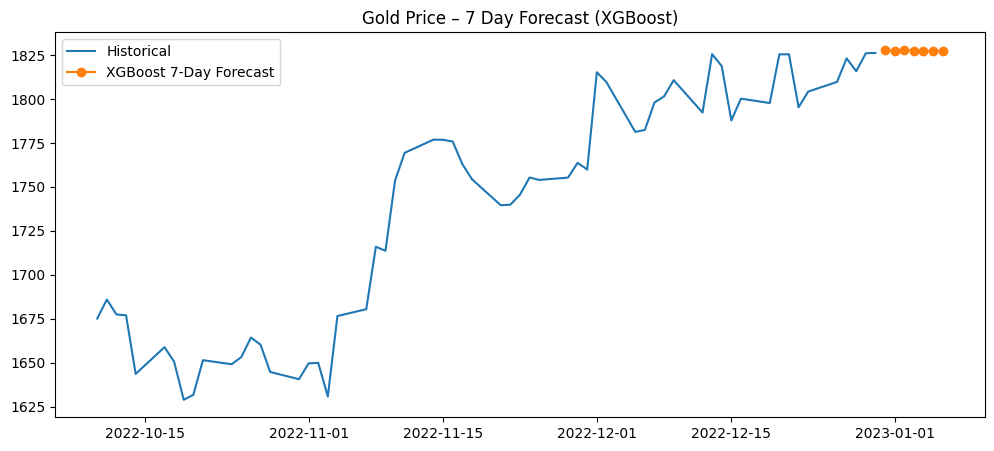

In [74]:
plt.figure(figsize=(12,5))

plt.plot(df['date'].iloc[-60:], df['price'].iloc[-60:], label='Historical')
plt.plot(
    forecast_7_days_xgb['date'],
    forecast_7_days_xgb['predicted_price'],
    marker='o',
    label='XGBoost 7-Day Forecast'
)

plt.legend()
plt.title("Gold Price – 7 Day Forecast (XGBoost)")
plt.show()

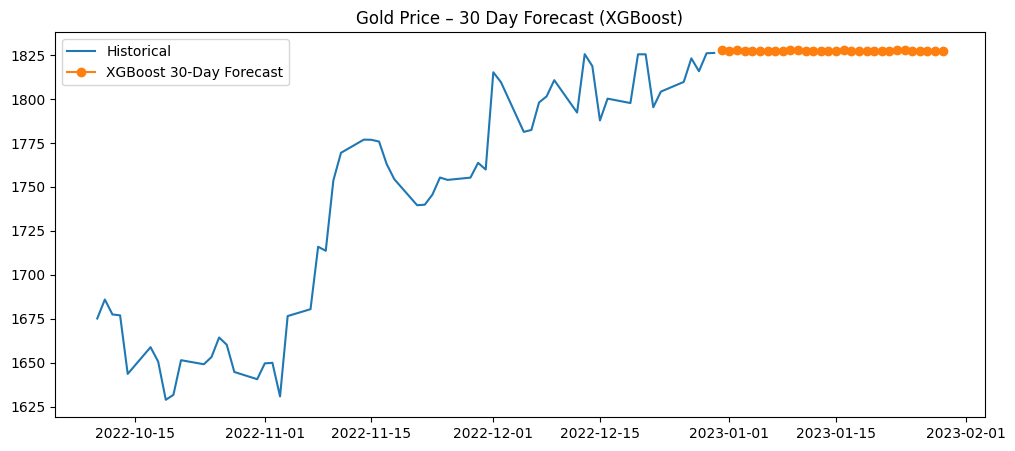

In [75]:
plt.figure(figsize=(12,5))

plt.plot(df['date'].iloc[-60:], df['price'].iloc[-60:], label='Historical')
plt.plot(
    forecast_30_days_xgb['date'],
    forecast_30_days_xgb['predicted_price'],
    marker='o',
    label='XGBoost 30-Day Forecast'
)

plt.legend()
plt.title("Gold Price – 30 Day Forecast (XGBoost)")
plt.show()

In [76]:
forecast_7_days_avg = forecast_7_days.copy()
forecast_7_days_avg['avg_price'] = (
    forecast_7_days['predicted_price'] +
    forecast_7_days_xgb['predicted_price']
) / 2

## LSTM (Long Short-Term Memory)

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Select Data

In [80]:
data = df[['price']].values

Scale the Data

In [81]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

Create Sequences (Use last 30 days → predict next day)

In [82]:
def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(scaled_data, 30)


In [83]:
split = int(len(X_lstm) * 0.8)

X_train = X_lstm[:split]
X_test  = X_lstm[split:]

y_train = y_lstm[:split]
y_test  = y_lstm[split:]

Reshape for LSTM Input

In [84]:
# An LSTM (Long Short-Term Memory) needs to see the "Flow of Time." It expects a 3D input structure: [Batch Size, Time Steps, Features]
# Batch Size (X_train.shape[0]): The total number of rows (e.g., 2,059 days).
# Time Steps (X_train.shape[1]): The number of features you are using as a "sequence" (e.g., if you have 5 lag columns, the time step is 5).
# Features (1): Since this is a Univariate LSTM, you are telling the model there is only one measurement per time step.

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

Build LSTM Model

In [87]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential([
    # This is the modern way to define the shape (Time Steps, Features)
    Input(shape=(X_train.shape[1], 1)),

    LSTM(50, return_sequences=True),  # 50 → number of memory units
    Dropout(0.2),  # prevents overfitting

    LSTM(50, return_sequences=False), # False is default here
    Dropout(0.2),

    Dense(1)  # predicts price
])

model.compile(optimizer='adam', loss='mean_squared_error')

Train LSTM Model

In [88]:
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0168 - val_loss: 0.0014
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0024 - val_loss: 0.0017
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0022 - val_loss: 0.0011
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0015 - val_loss: 8.8438e-04
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0019 - val_loss: 7.9321e-04
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0013 - val_loss: 7.9948e-04
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

Evaluate LSTM

In [89]:
y_pred = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [90]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lstm = mean_absolute_error(y_test_actual, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2_lstm = r2_score(y_test_actual, y_pred)

print(mae_lstm, rmse_lstm, r2_lstm)

18.689985437899065 24.463132616076468 0.8874131655561909


Predict Tomorrow (LSTM)

In [91]:
last_30 = scaled_data[-30:]
last_30 = last_30.reshape(1, 30, 1)

tomorrow_scaled = model.predict(last_30)
tomorrow_price = scaler.inverse_transform(tomorrow_scaled)

print("Tomorrow Price (LSTM):", round(tomorrow_price[0][0], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Tomorrow Price (LSTM): 1816.66
